<a href="https://colab.research.google.com/github/Bhanvi08/ML-Predictive-Modeling-Suite/blob/main/Bhanvi_Growth_and_Maturity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- SUPERVISED PERFORMANCE (Random Forest) ---
Accuracy: 79.55%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       421
           1       0.79      0.81      0.80       415

    accuracy                           0.80       836
   macro avg       0.80      0.80      0.80       836
weighted avg       0.80      0.80      0.80       836



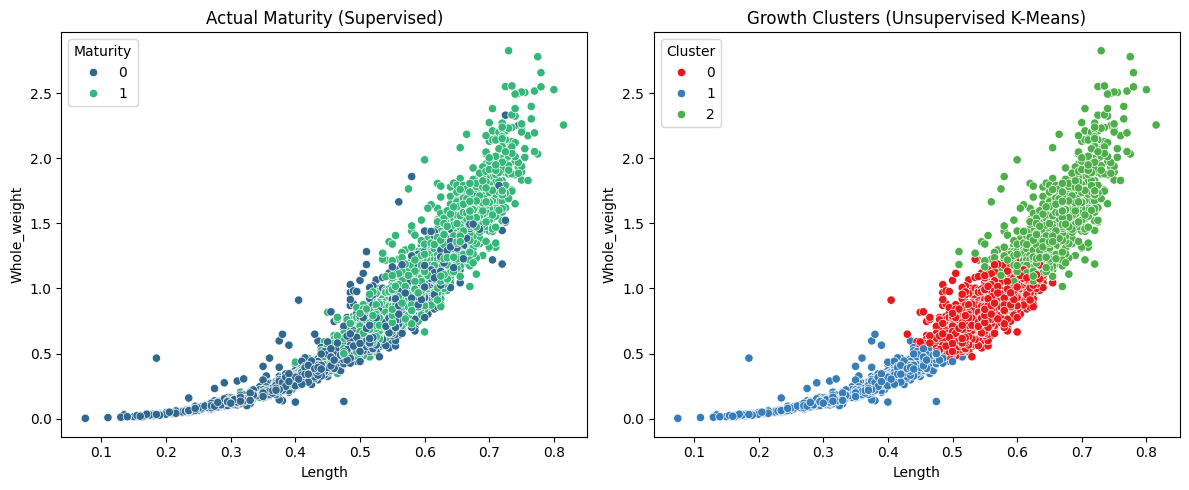


--- HYBRID INSIGHT ---
Cluster vs Maturity Alignment:
         Young  Mature
Cluster               
0          827     954
1         1065     183
2          204     944


In [ ]:
# ---------------------------------------------------------
# EcoShell Hybrid AI: Growth and Maturity Analysis using Machine Learning
# Bhanvi Singh Chauhan
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Abalone Dataset from UCI
columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
           'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
df = pd.read_csv(url, names=columns)

# 2. PRE-PROCESSING & LABELING
# Define Maturity: If Rings > 9, it's 'Mature' (1), else 'Young' (0)
df['Maturity'] = (df['Rings'] > 9).astype(int)

# Encode Categorical 'Sex' (M, F,) into numbers
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# Features for both models
X = df.drop(['Rings', 'Maturity'], axis=1)
y = df['Maturity']

# Scaling is crucial for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. STAGE 1: SUPERVISED LEARNING
# Using Random Forest to predict Maturity
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
wh
# 4. STAGE 2: UNSUPERVISED LEARNING
# We choose K=3 (Young, Adult, Senior)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# ---------------------------------------------------------
# RESULTS & VISUALIZATION
# ---------------------------------------------------------

print("--- SUPERVISED PERFORMANCE (Random Forest) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plotting Clusters
plt.figure(figsize=(12, 5))

# Plot 1: Supervised Labels (Actual Maturity)
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['Length'], y=df['Whole_weight'], hue=df['Maturity'], palette='viridis')
plt.title("Actual Maturity (Supervised)")

# Plot 2: Unsupervised Clusters (K-Means Discovery)
plt.subplot(1, 2, 2)
sns.scatterplot(x=df['Length'], y=df['Whole_weight'], hue=df['Cluster'], palette='Set1')
plt.title("Growth Clusters (Unsupervised K-Means)")

plt.tight_layout()
plt.show()

print("\n--- HYBRID INSIGHT ---")
# Check how many 'Mature' abalones fell into each cluster
comparison = pd.crosstab(df['Cluster'], df['Maturity'])
comparison.columns = ['Young', 'Mature']
print("Cluster vs Maturity Alignment:")
print(comparison)

**The Concept:** "I built a hybrid system that analyzes Abalone growth. It combines Supervised Learning (Random Forest) to predict maturity and Unsupervised Learning (K-Means) to discover natural biological groupings."
Supervised Part: "I used Random Forest from Unit 4. I defined a threshold for maturity based on the number of rings. The model predicts with [X]% accuracy whether an abalone is mature based on physical measurements like weight and shell diameter."

**Unsupervised Part:** "Then, I applied K-Means Clustering from Unit 5. I wanted to see if the AI could group the abalones without being given any labels. The AI naturally found 3 clusters which, as you can see in my visualization, correspond closely to the different growth stages (Juvenile, Adult, and Senior)."

**Handling Challenges:** "I used Standard Scaling because K-Means is sensitive to the magnitude of data. I also evaluated the model using Precision and Recall because this dataset has a class imbalance—finding the rare mature ones is more important than overall accuracy.